# Tarea M20-CD- YAIR PALOMARES

## Considere nuevamente la base de datos siguiente: FuelConsumptionCo2.xlsx

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os
import warnings

In [111]:
df = pd.read_excel("FuelConsumptionCo2.xlsx")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2022,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,200
1,2022,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263
2,2022,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,Z,11.0,8.6,9.9,29,232
3,2022,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,Z,11.3,9.1,10.3,27,242
4,2022,Acura,TLX SH-AWD,Compact,2.0,4,AS10,Z,11.2,8.0,9.8,29,230


## Elimine las columnas de tipo categórico de la base de datos y verifique que no existan datos nulos que deban ser eliminados de manera previa al análisis.

In [78]:
df.dtypes

MODELYEAR                     int64
MAKE                         object
MODEL                        object
VEHICLECLASS                 object
ENGINESIZE                  float64
CYLINDERS                     int64
TRANSMISSION                 object
FUELTYPE                     object
FUELCONSUMPTION_CITY        float64
FUELCONSUMPTION_HWY         float64
FUELCONSUMPTION_COMB        float64
FUELCONSUMPTION_COMB_MPG      int64
CO2EMISSIONS                  int64
dtype: object

In [112]:
df.drop(columns = ["MAKE", "MODEL", "VEHICLECLASS", "TRANSMISSION", "FUELTYPE"], inplace=True)
df

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2022,2.4,4,9.9,7.0,8.6,33,200
1,2022,3.5,6,12.6,9.4,11.2,25,263
2,2022,2.0,4,11.0,8.6,9.9,29,232
3,2022,2.0,4,11.3,9.1,10.3,27,242
4,2022,2.0,4,11.2,8.0,9.8,29,230
...,...,...,...,...,...,...,...,...
940,2022,2.0,4,10.7,7.7,9.4,30,219
941,2022,2.0,4,10.5,8.1,9.4,30,219
942,2022,2.0,4,11.0,8.7,9.9,29,232
943,2022,2.0,4,11.5,8.4,10.1,28,236


<Axes: >

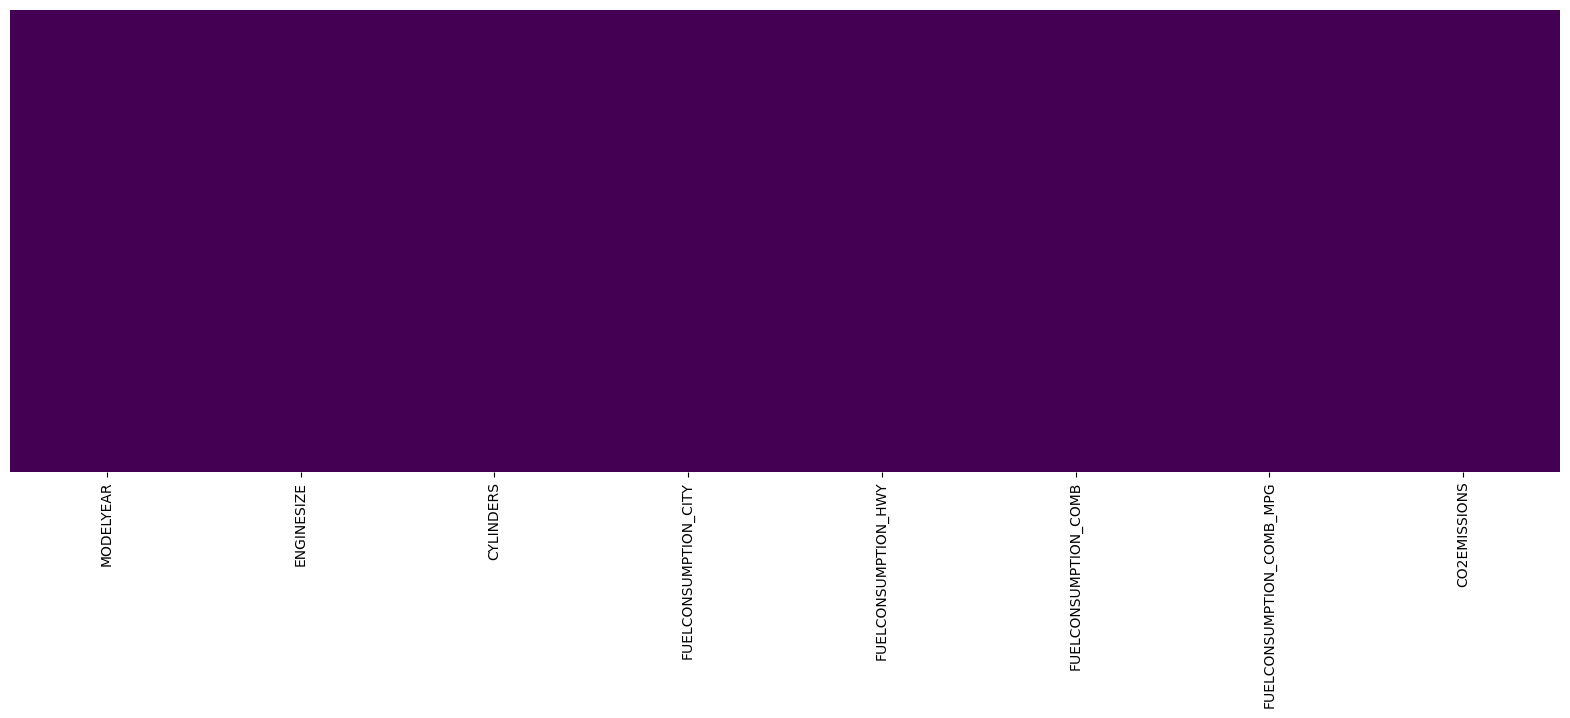

In [113]:
#Verificando si hay datos nulos en la base de datos
plt.figure(figsize=(20,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")

## Realice un análisis de regresión múltiple para pronosticar la variable “CO2 EMISSIONS” con las variables remanentes. Obtenga los indicadores de bondad de ajuste correspondientes (R cuadrada, Error medio absoluto, etc.). Utilice los coeficientes resultantes y pronostique la primera observación de la base de prueba. ¿Coincide su resultado con aquel obtenido con la instrucción “predict”? Explique.

In [114]:
#Definición de variable dependiente y variables independientes
y = df["CO2EMISSIONS"]
x = df.drop(columns=["CO2EMISSIONS"])

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import Normalizer

#División en grupos de entrenamiento y de prueba.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 1)

#Normalización de variables independientes
norm = Normalizer()
x_train_norm = norm.transform(x_train)
x_test_norm = norm.transform(x_test)

#Ajuste de modelo de regresión lineal múltiple.
linreg = LinearRegression()
linreg.fit(x_train_norm, y_train)

LinearRegression()

In [116]:
#Cálculo de indicadores de la bondad de ajuste
from sklearn.metrics import r2_score
from sklearn import metrics

#Cálculo de predicciones
y_pred = linreg.predict(x_test_norm)

#Impresión de indicadores de bondad de ajuste
print("Valor de R cuadrada: ", r2_score(y_test, y_pred))
print("Error absoluto medio: ", metrics.mean_absolute_error(y_test, y_pred))
print("Error cuadrático medio: ", metrics.mean_squared_error(y_test, y_pred))
print("Raíz del error cuadrático medio: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Valor de R cuadrada:  0.9785788322977577
Error absoluto medio:  5.980597587913508
Error cuadrático medio:  81.97577898244224
Raíz del error cuadrático medio:  9.054047657398444


In [122]:
valor_1_pronostico = 673799.4287870198 + (-673344.34070171)*0.99987025 + (-1044.61786281)*0.00197798 + 9776.4470572*0.00296697 + (-8048.87207764)*0.00771413 + (-3763.34870969)*0.0062801 + 7485.80221284*0.00707129 + (-22130.58963779)*0.00988991
print("Resultado con la instrucción predict: ", y_pred[0])
print("Resultado utilizando los coeficientes: ", valor_1_pronostico)


Resultado con la instrucción predict:  317.7328212003922
Resultado utilizando los coeficientes:  317.73519217389605


#### El resultado si coincide, ya que la instrucción predict calcula el resultado de la función del modelo estadístico.

## Repita el ejercicio 3 pero aplicando un modelo de regresión Ridge mediante el valor de Alpha óptimo.

In [129]:
#Definición de un rango de prueba para Alpha
alpha_range = 10.**np.arange(-5,5)
alpha_range

#Selección del Alpha óptimo
from sklearn.linear_model import RidgeCV
ridgeregcv = RidgeCV(alphas = alpha_range, scoring = "neg_mean_squared_error")
ridgeregcv.fit(x_train_norm, y_train)
print("Valor óptimo de alpha: "ridgeregcv.alpha_)
#Predicción mediante el mejor valor de alpha
y_pred = ridgeregcv.predict(x_test_norm)

#Impresión de indicadores de bondad de ajuste
print("Valor de R cuadrada: ", r2_score(y_test, y_pred))
print("Error absoluto medio: ", metrics.mean_absolute_error(y_test, y_pred))
print("Error cuadrático medio: ", metrics.mean_squared_error(y_test, y_pred))
print("Raíz del error cuadrático medio: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

1e-05
Valor de R cuadrada:  0.9778618048725993
Error absoluto medio:  6.357600243507036
Error cuadrático medio:  84.71974152202756
Raíz del error cuadrático medio:  9.204332758110583


## Repita el ejercicio 3 pero aplicando un modelo de regresión Lasso mediante el valor de Alpha óptimo.

In [132]:
#Selección del valor óptimo de alpha para la regresión Lasso
from sklearn.linear_model import LassoCV
lassoregcv = LassoCV(n_alphas=100, random_state=1)
lassoregcv.fit(x_train_norm, y_train)
print("Valor óptimo de alpha: ",lassoregcv.alpha_)
#Predicción mediante regresión de Lasso con un Alpha óptimo
y_pred = lassoregcv.predict(x_test_norm)

#Impresión de indicadores de bondad de ajuste
print("Valor de R cuadrada: ", r2_score(y_test, y_pred))
print("Error absoluto medio: ", metrics.mean_absolute_error(y_test, y_pred))
print("Error cuadrático medio: ", metrics.mean_squared_error(y_test, y_pred))
print("Raíz del error cuadrático medio: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Valor óptimo de alpha:  0.00022466802745368518
Valor de R cuadrada:  0.9775593566434242
Error absoluto medio:  6.404277182732142
Error cuadrático medio:  85.8771681167458
Raíz del error cuadrático medio:  9.266993477754573


## ¿Cuál de los 3 modelos de regresión resultó ser el mejor? Explique a detalle.

#### El modelo que se ajustó de mejor manera fue el modelo de regresión lineal múltiple. Para los modelos de regresión Ridge y Lasso, el valor óptimo de alpha que arrojaban de acuerdo al rango de experimentación siempre tendía a que fuera cero, esto significa no había sobre ajuste y no era necesario regularizar el modelo de regresión, ya que todas las variables independientes del análisis aportan en el comportamiento de las emisiones de CO2.